<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- [学習フェーズ開始 (K-Fold アンサンブル)] ---
>> 5分割交差検証を開始します...

--- Fold 1 ---
LightGBM     | Best Iteration: 203
[0]	validation_0-logloss:0.67214
[1]	validation_0-logloss:0.65449
[2]	validation_0-logloss:0.63840
[3]	validation_0-logloss:0.62406
[4]	validation_0-logloss:0.61016
[5]	validation_0-logloss:0.59937
[6]	validation_0-logloss:0.58756
[7]	validation_0-logloss:0.57864
[8]	validation_0-logloss:0.56905
[9]	validation_0-logloss:0.55942
[10]	validation_0-logloss:0.55131
[11]	validation_0-logloss:0.54271
[12]	validation_0-logloss:0.53371
[13]	validation_0-logloss:0.52455
[14]	validation_0-logloss:0.51668
[15]	validation_0-logloss:0.51015
[16]	validation_0-logloss:0.50577
[17]	validation_0-logloss:0.49833
[18]	validation_0-logloss:0.49191
[19]	validation_0-logloss:0.48676
[20]	validation_0-logloss:0.48207
[21]	validation_0-logloss:0.47700
[22]	validation_0-logloss:0.47167
[23]	validation_0-logloss:0.46907
[24]	validation_0-logloss:0.46467
[25]	validation_0-logloss:0.46078
[26]	validation_0-lo

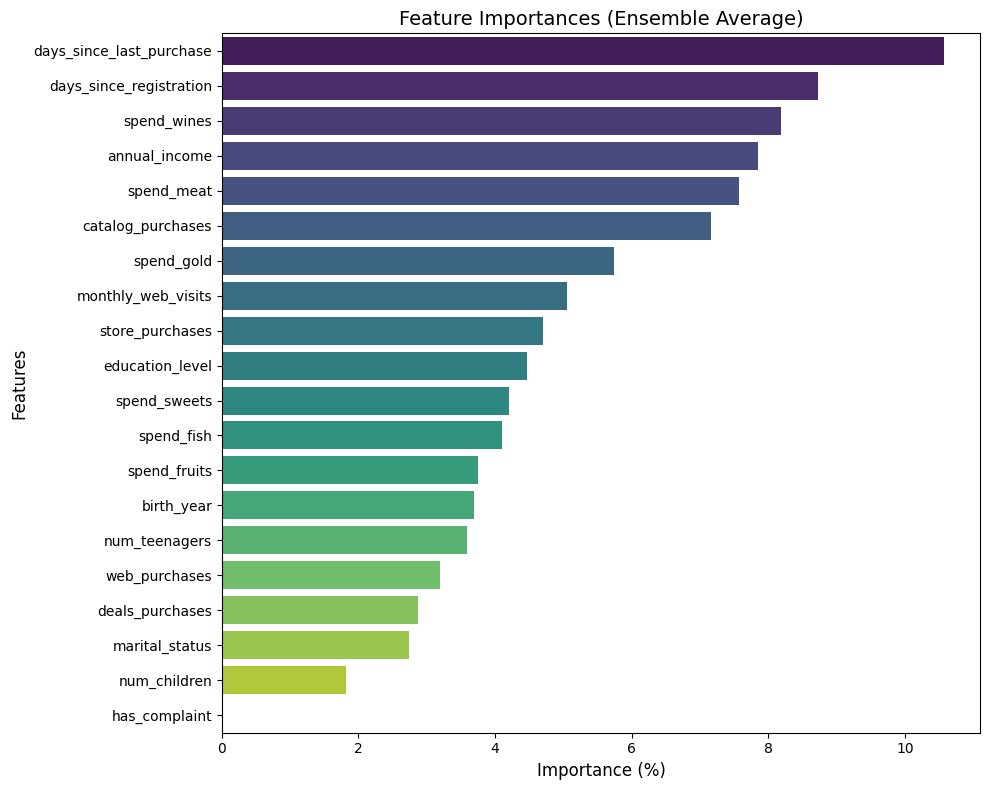


▼ 重要度ランキング上位5つ
                    Feature  Total_Average
0  days_since_last_purchase      10.573321
1   days_since_registration       8.725633
2               spend_wines       8.188721
3             annual_income       7.855211
4                spend_meat       7.566584


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, log_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore') # 警告を見やすくするため非表示

# ==========================================
# 1. 学習フェーズ用関数 (K-Fold アンサンブル対応)
# ==========================================
def train_marketing_models_with_cv(train_df, random_state=42, n_splits=5):
    """
    K-Fold交差検証を行い、各Foldの学習済みモデルと前処理器をすべて保存する。
    LightGBMとXGBoostにはEarly Stoppingを適用して過学習を防ぐ。
    """
    print("--- [学習フェーズ開始 (K-Fold アンサンブル)] ---")

    X = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']

    # --- 全体の前処理ルールを学習して適用 ---
    # 1. 日付処理
    base_date = pd.to_datetime('2015-01-01')
    def process_dates(df):
        df = df.copy()
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        return df.drop('registration_date', axis=1)

    X = process_dates(X)

    # 2. 欠損値補完 (全体のルール)
    income_median = X['annual_income'].median()
    X['annual_income'] = X['annual_income'].fillna(income_median)

    # 3. カテゴリ変数のエンコーディング (全体のルール)
    categorical_cols = ['education_level', 'marital_status']
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

    # 予測用関数に渡す状態を保存
    preprocess_state = {
        'income_median': income_median,
        'encoder': encoder,
        'cat_cols': categorical_cols,
        'base_date': base_date
    }

    # --- K-Fold 交差検証の準備 ---
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # 全Foldのモデルを保存するリスト
    trained_models = {'LightGBM': [], 'XGBoost': [], 'RandomForest': []}

    # 評価スコア記録用
    oof_preds = np.zeros(len(X)) # Out-Of-Fold 予測値

    print(f">> {n_splits}分割交差検証を開始します...")

    # Foldごとのループ
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Fold {fold + 1} ---")
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        # モデルの定義 (n_estimatorsを多めに設定し、Early Stoppingで止める)
        # XGBoost の early_stopping_rounds はコンストラクタで指定可能 (最新版)
        ratio = float(np.sum(y == 0)) / np.sum(y == 1)

        models = {
            'LightGBM': LGBMClassifier(
                random_state=random_state, n_estimators=1000, learning_rate=0.05, max_depth=5,
                class_weight='balanced',
                early_stopping_rounds=50, verbose=-1
            ),
            'XGBoost': XGBClassifier(
                random_state=random_state, n_estimators=1000, learning_rate=0.05, max_depth=5,
                scale_pos_weight=ratio,
                early_stopping_rounds=50, eval_metric='logloss'
            ),
            # RandomForestは構造上Early Stoppingが使えないため固定
            'RandomForest': RandomForestClassifier(random_state=random_state, n_estimators=100, max_depth=10,class_weight='balanced')
        }

        # Fold内での学習と予測
        fold_preds = np.zeros(len(X_val))

        for name, model in models.items():
            if name in ['LightGBM', 'XGBoost']:
                # GBDT系はEarly Stoppingを適用
                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)]
                )
                if name == 'LightGBM':
                    print(f"{name:12} | Best Iteration: {model.best_iteration_}")
                else:
                     print(f"{name:12} | Best Iteration: {model.best_iteration}")

            else:
                # RandomForest等はそのまま学習
                model.fit(X_train, y_train)

            # このFoldのValidationデータに対する予測確率
            val_pred = model.predict_proba(X_val)[:, 1]
            fold_preds += val_pred / len(models) # 3つのモデルの平均

            # 学習済みモデルを保存
            trained_models[name].append(model)

        # OOF(Out-Of-Fold)に記録
        oof_preds[val_idx] = fold_preds

        fold_auc = roc_auc_score(y_val, fold_preds)
        print(f">> Fold {fold + 1} Ensemble AUC: {fold_auc:.4f}")

    # --- 全体のCVスコア ---
    cv_auc = roc_auc_score(y, oof_preds)
    cv_loss = log_loss(y, oof_preds)
    print(f"\n>> 全体のCV AUC: {cv_auc:.4f} | CV LogLoss: {cv_loss:.4f}")
    print("--- [学習フェーズ完了] ---\n")

    return trained_models, preprocess_state


# ==========================================
# 2. 予測フェーズ用関数 (全モデルのアンサンブル)
# ==========================================
def predict_marketing_response_cv(test_df, trained_models_dict, preprocess_state):
    """
    保存された5Fold × 3アルゴリズム (計15個) のモデルすべてで予測し、
    その平均を最終予測値として出力する。
    """
    print("--- [予測フェーズ開始] ---")

    drop_cols = ['customer_id']
    if 'target' in test_df.columns:
        drop_cols.append('target')
    X_test = test_df.drop(drop_cols, axis=1)

    # --- 前処理の適用 ---
    # 1. 日付
    base_date = preprocess_state['base_date']
    X_test['days_since_registration'] = (base_date - pd.to_datetime(X_test['registration_date'])).dt.days
    X_test = X_test.drop('registration_date', axis=1)

    # 2. 欠損値
    X_test['annual_income'] = X_test['annual_income'].fillna(preprocess_state['income_median'])

    # 3. カテゴリ変数
    X_test[preprocess_state['cat_cols']] = preprocess_state['encoder'].transform(X_test[preprocess_state['cat_cols']])

    # --- 予測 (15個のモデルの平均) ---
    final_preds = np.zeros(len(X_test))
    total_models = 0

    for name, models_list in trained_models_dict.items():
        for model in models_list:
            # 確率予測を足し合わせる
            final_preds += model.predict_proba(X_test)[:, 1]
            total_models += 1

    # 合計モデル数(例: 3アルゴリズム×5Fold = 15)で割って平均を出す
    final_preds = final_preds / total_models

    print(f"計 {total_models} 個のモデルによるアンサンブル予測が完了しました。")
    print("--- [予測フェーズ完了] ---")

    return final_preds

def plot_feature_importances(trained_models_dict, feature_names):
    """
    K-Foldで学習した複数モデルの特徴量重要度を抽出し、
    平均をとって可視化する関数。
    """
    print("--- [特徴量重要度の算出] ---")

    # 重要度を格納するデータフレームを用意
    importance_df = pd.DataFrame({'Feature': feature_names})

    for model_name, models_list in trained_models_dict.items():
        # 5つのFoldモデルの重要度を合計するための配列
        fold_importances = np.zeros(len(feature_names))

        for model in models_list:
            # モデルから重要度を抽出
            fold_importances += model.feature_importances_

        # Fold数(5)で割って平均を出す
        importance_df[model_name] = fold_importances / len(models_list)

        # モデルごとのスケールを揃えるため、合計が100%になるように正規化
        importance_df[model_name] = (importance_df[model_name] / importance_df[model_name].sum()) * 100

    # 3つのアルゴリズムの「総合平均」を計算
    importance_df['Total_Average'] = importance_df[['LightGBM', 'XGBoost', 'RandomForest']].mean(axis=1)

    # 総合平均が高い順に並び替え
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    # --- グラフの描画 ---
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='Total_Average',
        y='Feature',
        data=importance_df,
        palette='viridis' # 色分け
    )

    plt.title('Feature Importances (Ensemble Average)', fontsize=14)
    plt.xlabel('Importance (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

    return importance_df

# ==========================================
# 3. 実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    # 1. 学習 (Early Stopping & K-Foldモデル保存)
    models_dict, state = train_marketing_models_with_cv(train_data, n_splits=5)

    # 2. 予測 (全モデルによるアンサンブル)
    final_predictions = predict_marketing_response_cv(test_data, models_dict, state)

    # 3. 出力
    submission = pd.read_csv('sample_submission.csv')
    submission['target'] = final_predictions
    submission.to_csv('final_submission_cv.csv', index=False)
    print("完了: 'final_submission_cv.csv' を出力しました。")

    feature_names = state['cat_cols'] + [c for c in train_data.drop(['customer_id', 'target', 'registration_date'], axis=1).columns if c not in state['cat_cols']] + ['days_since_registration']

    importance_results = plot_feature_importances(models_dict, feature_names)

    print("\n▼ 重要度ランキング上位5つ")
    print(importance_results[['Feature', 'Total_Average']].head(5))